In [35]:
import pandas as pd
import numpy as np

# Generate dummy sales data
dates = pd.date_range(start='2022-01-01', periods=100, freq='D')
sales = np.random.randint(100, 1000, size=100).astype(float)

# Introduce some missing values randomly
sales[np.random.choice(100, 5, replace=False)] = np.nan

dummy_data = pd.DataFrame({'Date': dates, 'Sales': sales})

# Save to a CSV file
dummy_data.to_csv('sales_data.csv', index=False)
print("Dummy 'sales_data.csv' created successfully.")

import pandas as pd

# 1. Read the CSV file into a Pandas DataFrame
df = pd.read_csv('sales_data.csv')

Dummy 'sales_data.csv' created successfully.


In [36]:
import pandas as pd

# 1. Read the CSV file into a Pandas DataFrame
df = pd.read_csv('sales_data.csv')

# 2. Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,Date,Sales
0,2022-01-01,747.0
1,2022-01-02,595.0
2,2022-01-03,464.0
3,2022-01-04,932.0
4,2022-01-05,441.0


In [37]:
import pandas as pd

# Ensure df is loaded if this cell is run independently
# If df is not in current kernel state, load it: df = pd.read_csv('sales_data.csv')

# 3. Check for missing values
print("Missing values before handling:")
display(df.isnull().sum())

# Handle missing values (e.g., fill with the mean of the 'Sales' column)
# A more robust strategy might be interpolation or dropping rows, depending on data context
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values before handling:


,0
Date,0
Sales,5



Missing values after handling:


,0
Date,0
Sales,0


/tmp/ipykernel_464/1110312259.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Sales'].resample('M').sum()


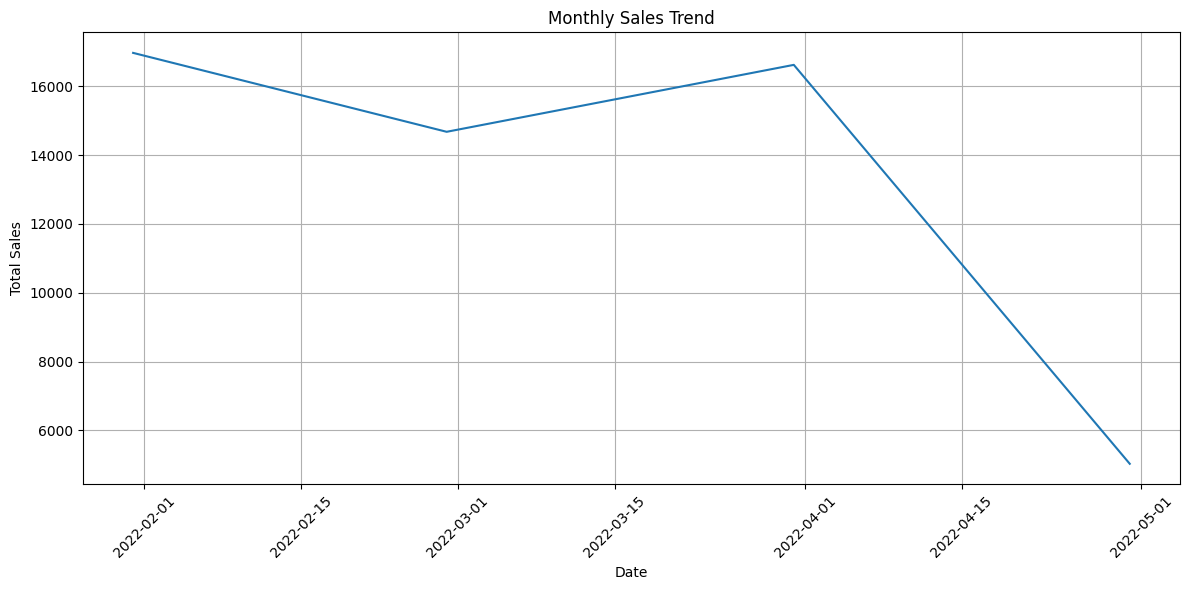

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded if this cell is run independently
# If df is not in current kernel state, load it: df = pd.read_csv('sales_data.csv')
# And handle missing values if not already done: df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as index for easier resampling
df.set_index('Date', inplace=True)

# Resample data to monthly frequency and sum sales
monthly_sales = df['Sales'].resample('M').sum()

# 4. Visualize the monthly sales trend using a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
